In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_621.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_258.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_062.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_1_penggerek_buah_kakao_351.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_1_penggerek_buah_kakao_807.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_154.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_365.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Penggerek Buah Kakao/train_dataset_2_pbk_271.jpg
/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026/Pengger

In [2]:
import warnings

warnings.filterwarnings("ignore")

# Cek Input Dataset pada Kaggle

In [3]:
print("Daftar dataset di /kaggle/input:")
print(os.listdir('/kaggle/input'))

Daftar dataset di /kaggle/input:
['datasets']


# Load Dataset

In [4]:
import tensorflow as tf
import pandas as pd
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

2026-08-27 18:33:28.113489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787855608.315459      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787855608.373870      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787855608.850380      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787855608.850456      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787855608.850460      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Keras: 3.13.2


In [5]:
path_dataset = '/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026'
path_dataset

'/kaggle/input/datasets/ahmadwafi/dataset-penelitian-kakao-2026'

In [6]:
dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset,
    labels="inferred",
    label_mode="categorical",
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names

print(class_names)

Found 6992 files belonging to 4 classes.


I0000 00:00:1787855629.779897      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787855629.785844      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


['Busuk Buah', 'Helopeltis', 'Kakao Sehat', 'Penggerek Buah Kakao']


# Pre-Processing

In [7]:
import tensorflow as tf

def preprocess(images, labels):
    # STANDARD COLOR RGB
    images = images[..., :3] 
    
    # RESIZE IMAGE (224 x 224)
    images = tf.image.resize(images, [224, 224])
    
    # NORMALIZATION
    images = tf.cast(images, tf.float32) / 255.0

    return images, labels

In [8]:
dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# CPU menyiapkan batch berikutnya selagi GPU sedang training
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

# Split Dataset

## Train (80%) Val (10%) Test (10%)

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

Found 6992 files belonging to 4 classes.
Using 5594 files for training.
Found 6992 files belonging to 4 classes.
Using 1398 files for validation.


In [11]:
val_batches = tf.data.experimental.cardinality(val_test_dataset)
half_val_batches = val_batches // 2

val_dataset = val_test_dataset.take(half_val_batches)
test_dataset = val_test_dataset.skip(half_val_batches)

In [12]:
def get_dataset_image_count(dataset):
    total_images = 0
    for images, labels in dataset:
        total_images += images.shape[0]  # Menghitung jumlah baris/gambar dalam batch
    return total_images

In [13]:
print("\n=== RINGKASAN JUMLAH DATASET ===")
print(f"Jumlah data TRAIN      : {get_dataset_image_count(train_dataset)} gambar")
print(f"Jumlah data VALIDATION : {get_dataset_image_count(val_dataset)} gambar")
print(f"Jumlah data TEST       : {get_dataset_image_count(test_dataset)} gambar")
print("================================")


=== RINGKASAN JUMLAH DATASET ===
Jumlah data TRAIN      : 5594 gambar
Jumlah data VALIDATION : 704 gambar
Jumlah data TEST       : 694 gambar


In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Model Arsitektur ResNet50

In [15]:
def build_resnet50():
    base_model = ResNet50(include_top=False, weights="imagenet", input_shape=(224,224,3))
    base_model.trainable = False
    
    inputs = Input(shape=(224,224,3))
    
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    outputs = Dense(4, activation="softmax")(x)
    model = Model(inputs, outputs)
    return model

# Model Arsitektur ResNet152V2

In [16]:
from tensorflow.keras.applications import ResNet152V2

In [17]:
def build_resnet152v2():
    base_model = ResNet152V2(include_top=False, weights='imagenet', input_shape=(224,224,3))
    base_model.trainable = False
    
    inputs = Input(shape=(224,224,3))

    x = base_model(inputs,training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# Convolutional Block Attention Module (CBAM)

### Channel Attention

In [21]:
def channel_attention(input_feature, ratio=8):
    channel = int(input_feature.shape[-1])
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalMaxPooling2D()(input_feature)

    shared_dense_1 = Dense(channel // ratio,activation="relu")
    shared_dense_2 = Dense(channel)
    avg = shared_dense_2(shared_dense_1(avg_pool))
    max_ = shared_dense_2(shared_dense_1(max_pool))

    attention = Add()([avg, max_])
    attention = Activation("sigmoid")(attention)
    attention = Reshape((1,1,channel))(attention)

    return Multiply()([input_feature, attention])

### Spatial Attention

In [19]:
def spatial_attention(input_feature):
    avg_pool = keras.ops.mean(input_feature, axis=-1, keepdims=True)
    max_pool = keras.ops.max(input_feature,axis=-1,keepdims=True)

    concat = Concatenate(axis=-1)([avg_pool,max_pool])

    attention = Conv2D(1,7, padding="same", activation="sigmoid")(concat)

    return Multiply()([input_feature, attention])

### CBAM Blocks

In [20]:
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
        
    return x

# Model Arsitektur ResNet50-CBAM

In [22]:
def build_resnet50_cbam_stage():
    inputs = Input(shape=(224,224,3))
    backbone = ResNet50(include_top=False,weights="imagenet",input_tensor=inputs)
    backbone.trainable = False

    # CONV2_X
    conv2 = backbone.get_layer("conv2_block3_out").output
    conv2 = cbam_block(conv2)

    # CONV3_X
    conv3 = backbone.get_layer("conv3_block4_out").output
    conv3 = cbam_block(conv3)

    # CONV4_X
    conv4 = backbone.get_layer("conv4_block6_out").output
    conv4 = cbam_block(conv4)
    
    # CONV5_X
    conv5 = backbone.get_layer("conv5_block3_out").output
    conv5 = cbam_block(conv5)

    # output stage terakhir
    x = conv5
    
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation="relu")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(4,activation="softmax")(x)

    model = Model(inputs,outputs)
    return model

# Training Model

In [23]:
tf.keras.backend.clear_session()

### Build Model Arsitektur ResNet50

In [24]:
model_resnet50 = build_resnet50()

model_resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [25]:
model_resnet50.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Build Model Arsitektur ResNet152V2

In [26]:
model_resnet152v2 = build_resnet152v2()

model_resnet152v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [27]:
model_resnet152v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,857,220 (224.52 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

### Build Model Arsitektur ResNet50-CBAM

In [28]:
model_resnet50_cbam = build_resnet50_cbam_stage()

model_resnet50_cbam.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model_resnet50_cbam.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,164,263 (95.99 MB)

 Trainable params: 1,576,551 (6.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Split dataset (X_train, y_train, X_val, y_val, X_test)

In [30]:
import numpy as np

def dataset_to_numpy(dataset, with_labels=True):
    X = []
    y = []
    
    for batch in dataset:
        if with_labels:
            images, labels = batch
            X.append(images.numpy())
            y.append(labels.numpy())
        else:
            X.append(batch.numpy())
    
    X = np.concatenate(X,axis=0)
    if with_labels:
        y = np.concatenate(y,axis=0)
        return X, y
    
    return X

In [31]:
X_train, y_train = dataset_to_numpy(train_dataset)

X_val, y_val = dataset_to_numpy(val_dataset)

X_test, y_test = dataset_to_numpy(test_dataset)

In [32]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(5594, 224, 224, 3)
(5594, 4)
(704, 224, 224, 3)
(704, 4)
(694, 224, 224, 3)
(694, 4)


### Train & Eval Model Arsitektur ResNet50

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_resnet50 = model_resnet50.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=12, 
    batch_size=32, 
    callbacks=[early_stopping]
)

Epoch 1/12


I0000 00:00:1787855885.700049     140 service.cc:152] XLA service 0x7a3728003060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787855885.700103     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1787855885.700107     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1787855887.489563     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/175 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.2266 - loss: 2.0815 

I0000 00:00:1787855892.843754     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.7369 - loss: 0.6947 - val_accuracy: 0.8821 - val_loss: 0.3562
Epoch 2/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.8772 - loss: 0.3447 - val_accuracy: 0.9105 - val_loss: 0.2770
Epoch 3/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9088 - loss: 0.2675 - val_accuracy: 0.9247 - val_loss: 0.2316
Epoch 4/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9262 - loss: 0.2154 - val_accuracy: 0.9276 - val_loss: 0.2071
Epoch 5/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 0.9398 - loss: 0.1799 - val_accuracy: 0.9261 - val_loss: 0.2107
Epoch 6/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9476 - loss: 0.1576 - val_accuracy: 0.9361 - val_loss: 0.1767
Epoch 7/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9526 - loss: 0.1392 - val_accuracy: 0.9432 - val_loss: 0.1667
Epoch 8/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9569 - loss: 0.1232 - val

In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Fungsi untuk memplot akurasi dan loss
def plot_history(history):
    # Plot akurasi
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Akurasi Pelatihan')
    plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
    plt.title('Akurasi Model')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss Pelatihan')
    plt.plot(history.history['val_loss'], label='Loss Validasi')
    plt.title('Loss Model')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

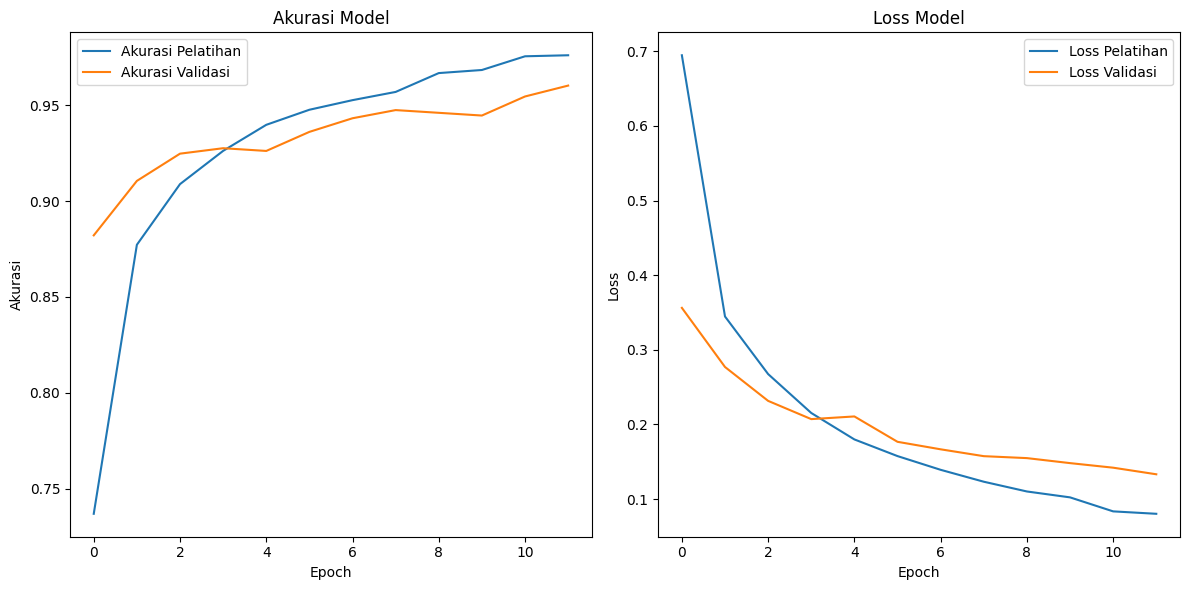

In [35]:
# Plot akurasi dan loss
plot_history(history_resnet50)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step


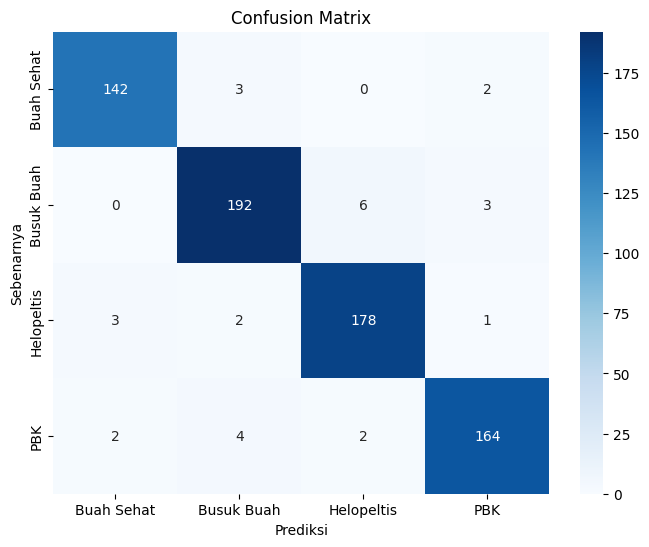

Accuracy: 96.02%
Classification Report:
               precision    recall  f1-score   support

  Buah Sehat       0.97      0.97      0.97       147
  Busuk Buah       0.96      0.96      0.96       201
  Helopeltis       0.96      0.97      0.96       184
         PBK       0.96      0.95      0.96       172

    accuracy                           0.96       704
   macro avg       0.96      0.96      0.96       704
weighted avg       0.96      0.96      0.96       704



In [36]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prediksi probabilitas untuk setiap kelas
val_predictions_resnet50 = model_resnet50.predict(X_val)

# Konversi prediksi probabilitas ke label kelas (0, 1, 2, atau 3)
val_predicted_classes = np.argmax(val_predictions_resnet50, axis=1)

# Konversi label one-hot encoding ke label numerik (0, 1, 2, atau 3)
val_labels_array = np.argmax(y_val, axis=1)

# Hitung confusion matrix
cm = confusion_matrix(val_labels_array, val_predicted_classes)

# Nama kelas sesuai dataset Kakao
class_names = ["Buah Sehat", "Busuk Buah", "Helopeltis", "PBK"]

# Visualisasi confusion matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Prediksi')
    plt.ylabel('Sebenarnya')
    plt.show()

# Tampilkan confusion matrix
plot_confusion_matrix(cm)

# Hitung dan tampilkan akurasi
accuracy_val_resnet50 = accuracy_score(val_labels_array, val_predicted_classes)
print(f"Accuracy: {accuracy_val_resnet50 * 100:.2f}%")

# Tampilkan classification report
print("Classification Report:\n", classification_report(val_labels_array, val_predicted_classes, target_names=class_names))

In [37]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (roc_curve, auc)

from tensorflow.keras.utils import (to_categorical)


def plot_multiclass_roc(y_true,y_pred_prob,class_names):
    
    if len(y_true.shape) == 1:
        y_true = to_categorical(y_true, num_classes=len(class_names))
        
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:,i],y_pred_prob[:,i])
        auc_score = auc(fpr,tpr)
        plt.plot(fpr,tpr,linewidth=2,label=f"{class_name} (AUC={auc_score:.3f})")

    plt.plot([0,1],[0,1],"k--")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-Class ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

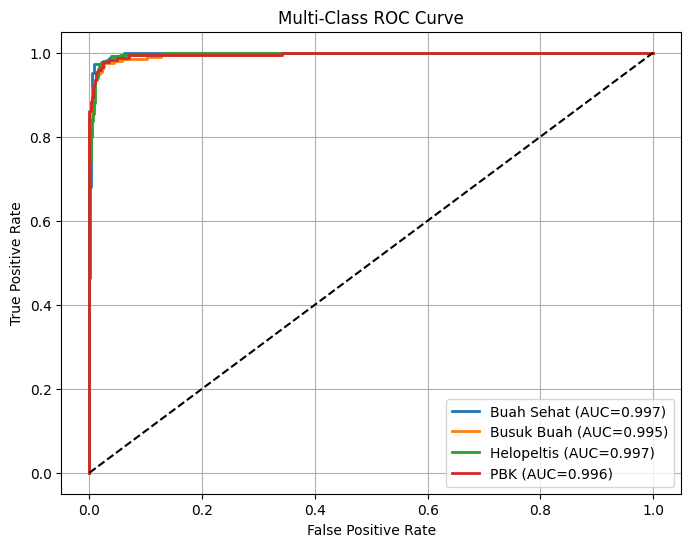

In [38]:
plot_multiclass_roc(
    y_val,
    val_predictions_resnet50,
    class_names
)

### Train & Eval Model Arsitektur ResNet152V2

In [39]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_resnet152v2 = model_resnet152v2.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=12, 
    batch_size=32, 
    callbacks=[early_stopping]
)

Epoch 1/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 365ms/step - accuracy: 0.3312 - loss: 60.3967 - val_accuracy: 0.3906 - val_loss: 1.3001
Epoch 2/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 44s 254ms/step - accuracy: 0.3257 - loss: 1.3806 - val_accuracy: 0.3352 - val_loss: 1.3587
Epoch 3/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 240ms/step - accuracy: 0.2912 - loss: 1.3563 - val_accuracy: 0.3580 - val_loss: 1.3100
Epoch 4/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 248ms/step - accuracy: 0.3089 - loss: 1.3532 - val_accuracy: 0.3267 - val_loss: 1.3301


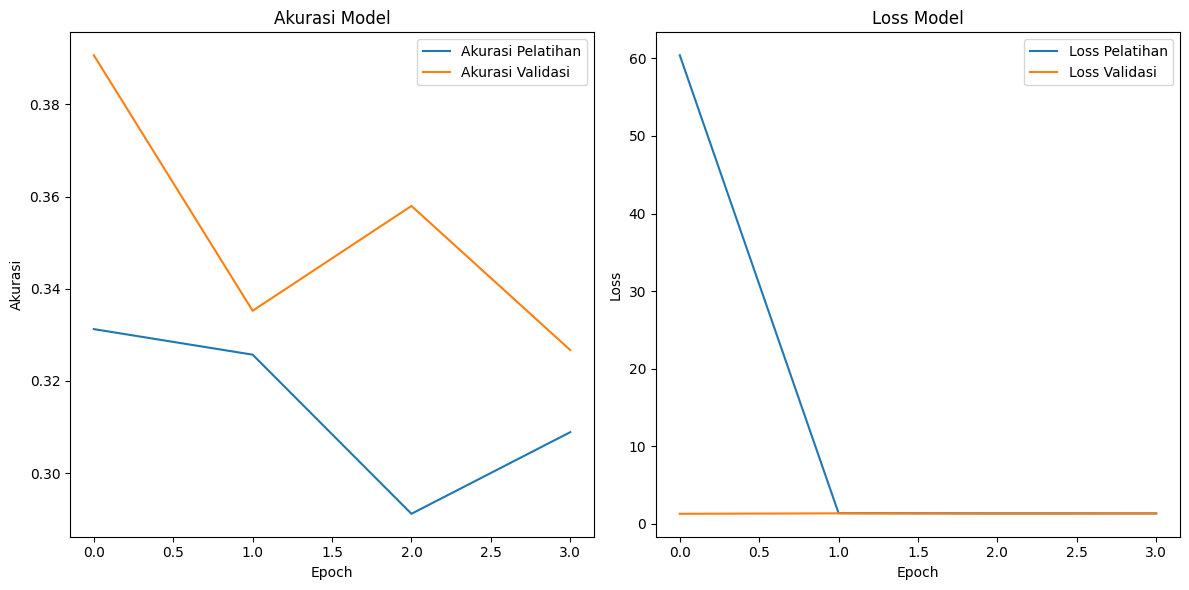

In [40]:
# Plot akurasi dan loss
plot_history(history_resnet152v2)

22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step


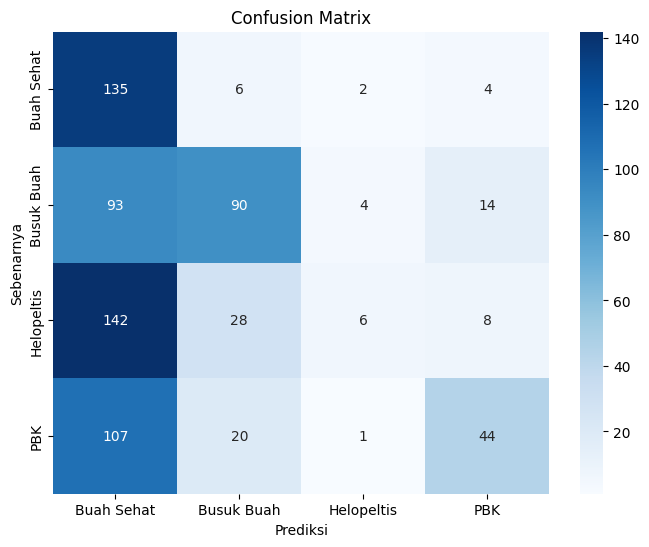

Accuracy: 39.06%
Classification Report:
               precision    recall  f1-score   support

  Buah Sehat       0.28      0.92      0.43       147
  Busuk Buah       0.62      0.45      0.52       201
  Helopeltis       0.46      0.03      0.06       184
         PBK       0.63      0.26      0.36       172

    accuracy                           0.39       704
   macro avg       0.50      0.41      0.34       704
weighted avg       0.51      0.39      0.34       704



In [41]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prediksi probabilitas untuk setiap kelas
val_predictions_resnet152v2 = model_resnet152v2.predict(X_val)

# Konversi prediksi probabilitas ke label kelas (0, 1, 2, atau 3)
val_predicted_classes = np.argmax(val_predictions_resnet152v2, axis=1)

# Konversi label one-hot encoding ke label numerik (0, 1, 2, atau 3)
val_labels_array = np.argmax(y_val, axis=1)

# Hitung confusion matrix
cm = confusion_matrix(val_labels_array, val_predicted_classes)

# Nama kelas sesuai dataset Kakao
class_names = ["Buah Sehat", "Busuk Buah", "Helopeltis", "PBK"]

# Visualisasi confusion matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Prediksi')
    plt.ylabel('Sebenarnya')
    plt.show()

# Tampilkan confusion matrix
plot_confusion_matrix(cm)

# Hitung dan tampilkan akurasi
accuracy_val_resnet152v2 = accuracy_score(val_labels_array, val_predicted_classes)
print(f"Accuracy: {accuracy_val_resnet152v2 * 100:.2f}%")

# Tampilkan classification report
print("Classification Report:\n", classification_report(val_labels_array, val_predicted_classes, target_names=class_names))

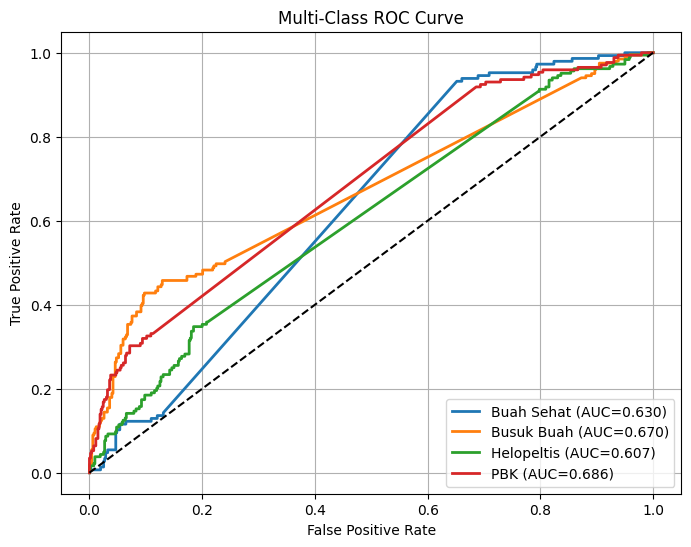

In [42]:
plot_multiclass_roc(
    y_val,
    val_predictions_resnet152v2,
    class_names
)

### Train & Eval Model Arsitektur ResNet50-CBAM

In [43]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_resnet50_cbam = model_resnet50_cbam.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=12, 
    batch_size=32, 
    callbacks=[early_stopping]
)

Epoch 1/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 174ms/step - accuracy: 0.7835 - loss: 0.5734 - val_accuracy: 0.8920 - val_loss: 0.3108
Epoch 2/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9140 - loss: 0.2500 - val_accuracy: 0.9162 - val_loss: 0.2473
Epoch 3/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9435 - loss: 0.1688 - val_accuracy: 0.9418 - val_loss: 0.1856
Epoch 4/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9591 - loss: 0.1140 - val_accuracy: 0.9304 - val_loss: 0.1991
Epoch 5/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9752 - loss: 0.0765 - val_accuracy: 0.9389 - val_loss: 0.1545
Epoch 6/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9832 - loss: 0.0540 - val_accuracy: 0.9460 - val_loss: 0.1669
Epoch 7/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9855 - loss: 0.0441 - val_accuracy: 0.9418 - val_loss: 0.1653
Epoch 8/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9939 - loss: 0

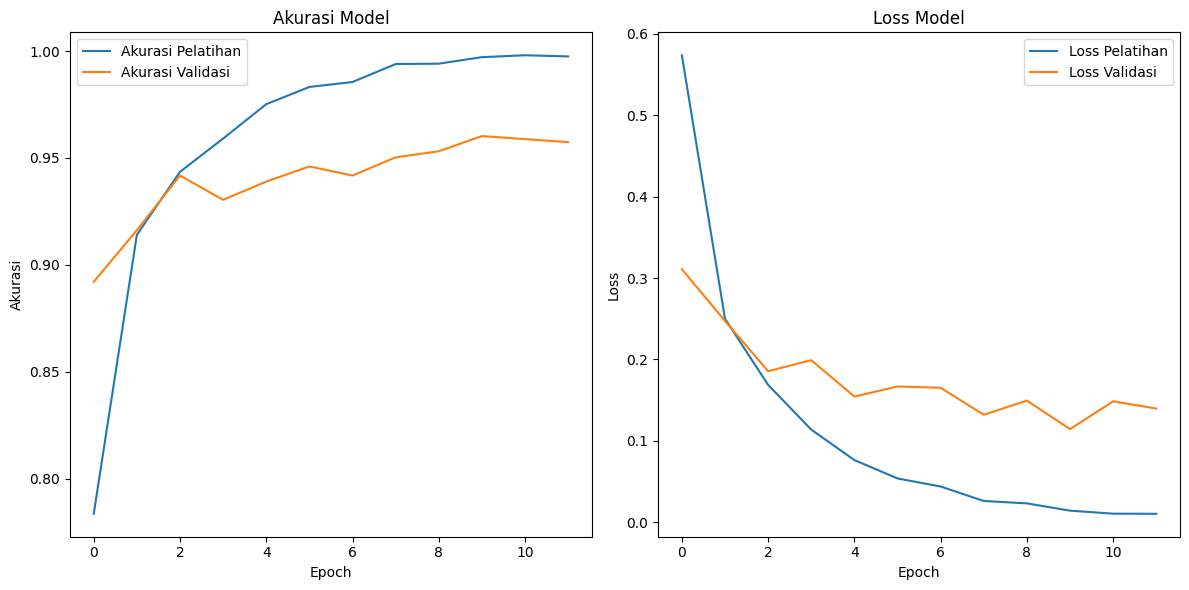

In [44]:
# Plot akurasi dan loss
plot_history(history_resnet50_cbam)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step


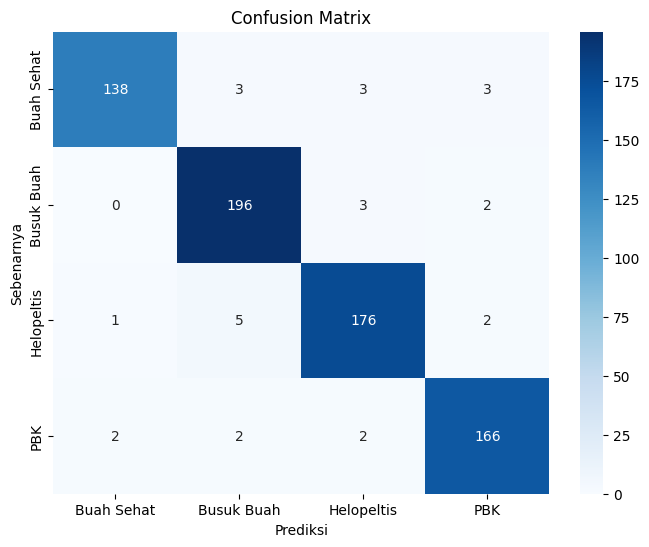

Accuracy: 96.02%
Classification Report:
               precision    recall  f1-score   support

  Buah Sehat       0.98      0.94      0.96       147
  Busuk Buah       0.95      0.98      0.96       201
  Helopeltis       0.96      0.96      0.96       184
         PBK       0.96      0.97      0.96       172

    accuracy                           0.96       704
   macro avg       0.96      0.96      0.96       704
weighted avg       0.96      0.96      0.96       704



In [45]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prediksi probabilitas untuk setiap kelas
val_predictions_resnet50_cbam = model_resnet50_cbam.predict(X_val)

# Konversi prediksi probabilitas ke label kelas (0, 1, 2, atau 3)
val_predicted_classes = np.argmax(val_predictions_resnet50_cbam, axis=1)

# Konversi label one-hot encoding ke label numerik (0, 1, 2, atau 3)
val_labels_array = np.argmax(y_val, axis=1)

# Hitung confusion matrix
cm = confusion_matrix(val_labels_array, val_predicted_classes)

# Nama kelas sesuai dataset Kakao
class_names = ["Buah Sehat", "Busuk Buah", "Helopeltis", "PBK"]

# Visualisasi confusion matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Prediksi')
    plt.ylabel('Sebenarnya')
    plt.show()

# Tampilkan confusion matrix
plot_confusion_matrix(cm)

# Hitung dan tampilkan akurasi
accuracy_val_resnet50_cbam = accuracy_score(val_labels_array, val_predicted_classes)
print(f"Accuracy: {accuracy_val_resnet50_cbam * 100:.2f}%")

# Tampilkan classification report
print("Classification Report:\n", classification_report(val_labels_array, val_predicted_classes, target_names=class_names))

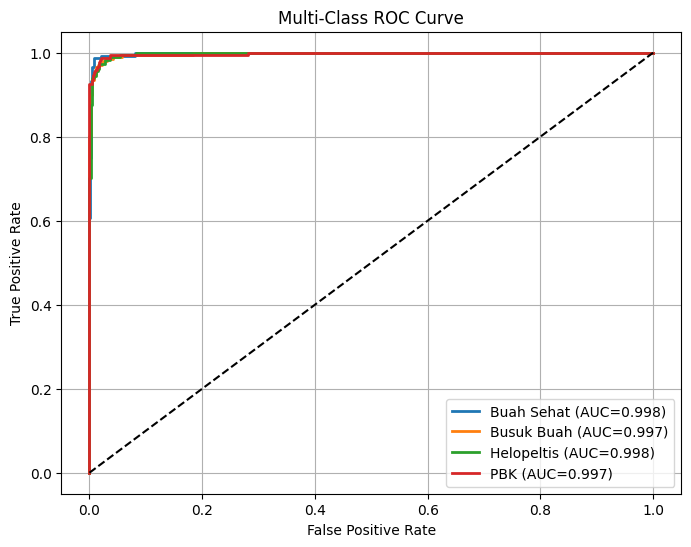

In [46]:
plot_multiclass_roc(
    y_val,
    val_predictions_resnet50_cbam,
    class_names
)

# Testing

### Model Arsitektur ResNet50

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 365ms/step


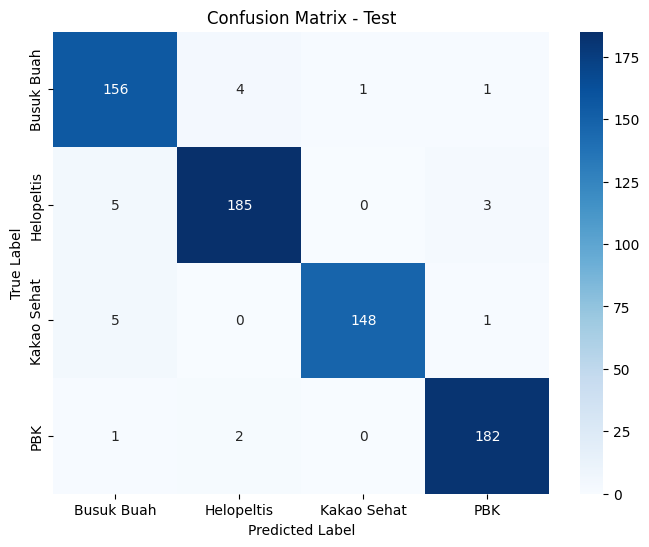

Accuracy: 96.69%
              precision    recall  f1-score   support

  Busuk Buah       0.93      0.96      0.95       162
  Helopeltis       0.97      0.96      0.96       193
 Kakao Sehat       0.99      0.96      0.98       154
         PBK       0.97      0.98      0.98       185

    accuracy                           0.97       694
   macro avg       0.97      0.97      0.97       694
weighted avg       0.97      0.97      0.97       694



In [47]:
# PREDIKSI
y_pred_prob = model_resnet50.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

# LABEL ASLI
if len(y_test.shape) > 1:
    y_test_indices = np.argmax(y_test,axis=1)
else:
    y_test_indices = y_test

# CONFUSION MATRIX
conf_matrix = confusion_matrix(y_test_indices, y_pred)

class_names = [
    "Busuk Buah",
    "Helopeltis",
    "Kakao Sehat",
    "PBK"
]


plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test")
plt.show()

# ACCURACY
accuracy_resnet50_test = accuracy_score(y_test_indices, y_pred)

print(
    f"Accuracy: {accuracy_resnet50_test*100:.2f}%"
)


# REPORT
print(classification_report(
        y_test_indices,
        y_pred,
        target_names=class_names
    )
)

## Model Arsitektur ResNet152V2

22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 723ms/step


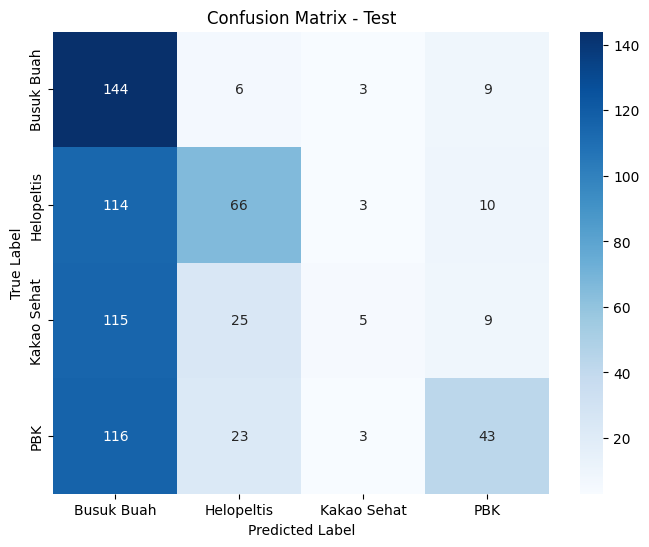

Accuracy: 37.18%
              precision    recall  f1-score   support

  Busuk Buah       0.29      0.89      0.44       162
  Helopeltis       0.55      0.34      0.42       193
 Kakao Sehat       0.36      0.03      0.06       154
         PBK       0.61      0.23      0.34       185

    accuracy                           0.37       694
   macro avg       0.45      0.37      0.31       694
weighted avg       0.46      0.37      0.32       694



In [48]:
# PREDIKSI
y_pred_prob = model_resnet152v2.predict(X_test)

y_pred_resnet152v2 = np.argmax(y_pred_prob, axis=1)

# LABEL ASLI
if len(y_test.shape) > 1:
    y_test_indices = np.argmax(y_test,axis=1)
else:
    y_test_indices = y_test

# CONFUSION MATRIX
conf_matrix = confusion_matrix(y_test_indices, y_pred_resnet152v2)

class_names = [
    "Busuk Buah",
    "Helopeltis",
    "Kakao Sehat",
    "PBK"
]


plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test")
plt.show()

# ACCURACY
accuracy_resnet152v2_test = accuracy_score(y_test_indices, y_pred_resnet152v2)

print(
    f"Accuracy: {accuracy_resnet152v2_test*100:.2f}%"
)


# REPORT
print(classification_report(
        y_test_indices,
        y_pred_resnet152v2,
        target_names=class_names
    )
)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 291ms/step


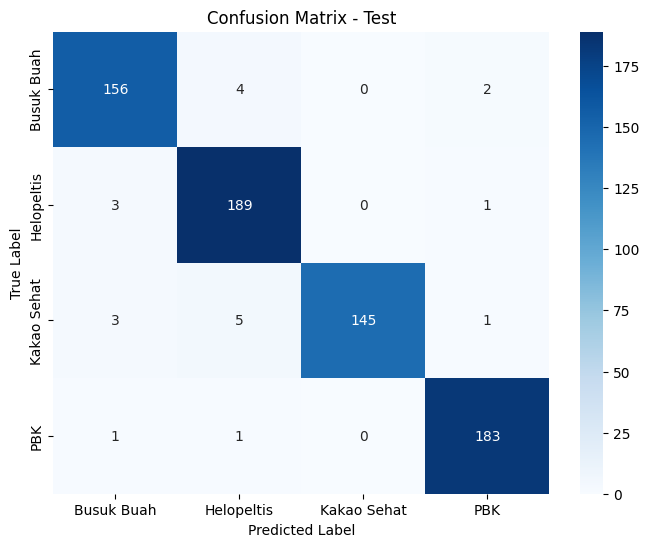

Accuracy: 96.97%
              precision    recall  f1-score   support

  Busuk Buah       0.96      0.96      0.96       162
  Helopeltis       0.95      0.98      0.96       193
 Kakao Sehat       1.00      0.94      0.97       154
         PBK       0.98      0.99      0.98       185

    accuracy                           0.97       694
   macro avg       0.97      0.97      0.97       694
weighted avg       0.97      0.97      0.97       694



In [49]:
# PREDIKSI
y_pred_prob = model_resnet50_cbam.predict(X_test)

y_pred_resnet50_cbam = np.argmax(y_pred_prob, axis=1)

# LABEL ASLI
if len(y_test.shape) > 1:
    y_test_indices = np.argmax(y_test,axis=1)
else:
    y_test_indices = y_test

# CONFUSION MATRIX
conf_matrix = confusion_matrix(y_test_indices, y_pred_resnet50_cbam)

class_names = [
    "Busuk Buah",
    "Helopeltis",
    "Kakao Sehat",
    "PBK"
]


plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test")
plt.show()

# ACCURACY
accuracy_resnet50_cbam_test = accuracy_score(y_test_indices, y_pred_resnet50_cbam)

print(
    f"Accuracy: {accuracy_resnet50_cbam_test*100:.2f}%"
)


# REPORT
print(classification_report(
        y_test_indices,
        y_pred_resnet50_cbam,
        target_names=class_names
    )
)

# Best Model Selection

In [50]:
results = {
    "ResNet50":
    accuracy_resnet50_test,

    "ResNet152V2":
    accuracy_resnet152v2_test,

    "ResNet50-CBAM":
    accuracy_resnet50_cbam_test

}

best_model = max(
    results,
    key=results.get
)

print(best_model)

ResNet50-CBAM


# Grad-CAM

In [51]:
import tensorflow as tf
import numpy as np
import cv2


def make_gradcam_heatmap(image, model, layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs],[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape: 
        conv_output, preds = grad_model(image)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]
            grads = tape.gradient(class_channel, conv_output)
            pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
            conv_output = conv_output[0]
            heatmap = (conv_output @ pooled_grads[...,tf.newaxis])
            heatmap = tf.squeeze(heatmap)
            heatmap = tf.maximum(heatmap, 0)
            heatmap /= (tf.reduce_max(heatmap) + 1e-8)
            return heatmap.numpy()

In [52]:
for images, labels in test_dataset.take(1):
    img = images[0]
    img_np = (img.numpy().astype("uint8"))
    input_image = tf.expand_dims(img, axis=0)
    label = tf.argmax(labels[0]).numpy()
    break

In [53]:
layers = [
    "conv2_block3_out",
    "conv3_block4_out",
    "conv4_block6_out",
    "conv5_block3_out"
]

In [54]:
heatmaps = []

for layer in layers:
    heatmap = make_gradcam_heatmap(input_image, model_resnet50_cbam, layer)
    heatmap = cv2.resize(heatmap,(224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap,0.4,0)
    heatmaps.append(overlay)

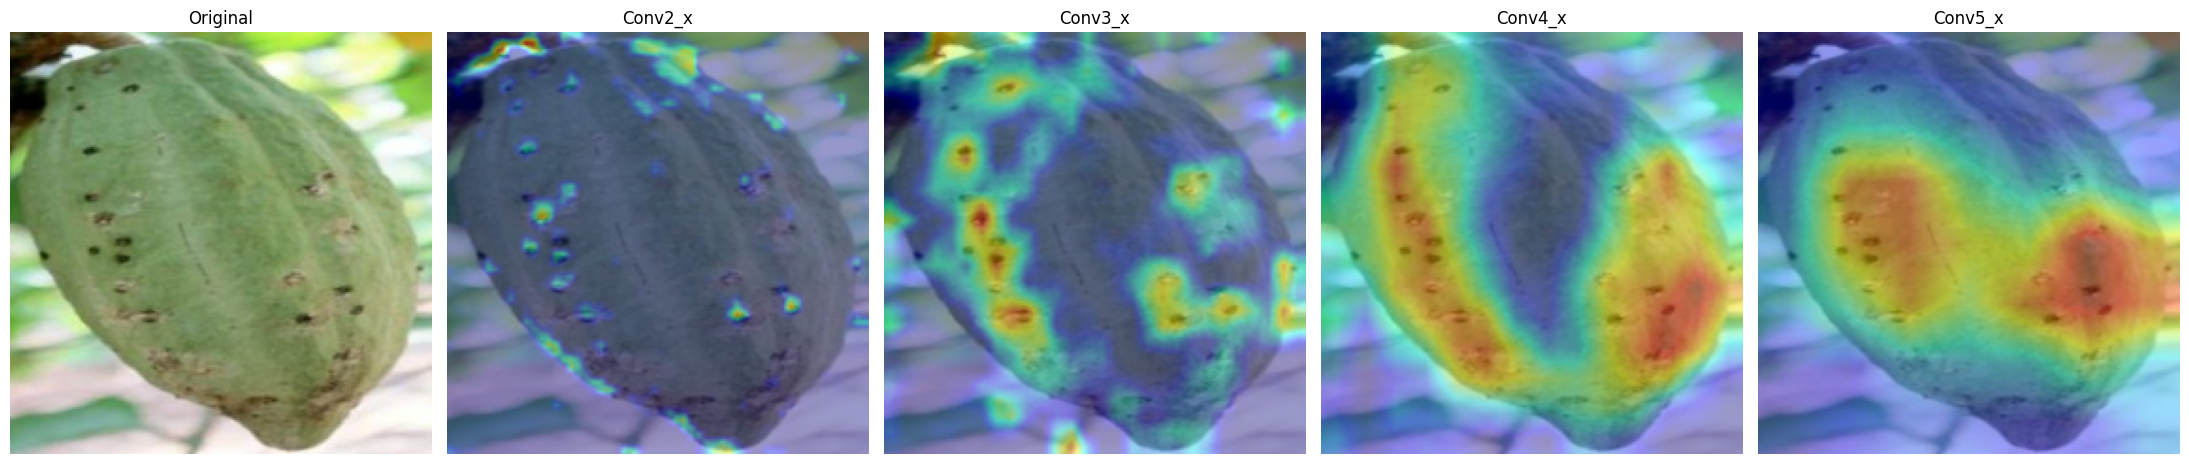

In [55]:
fig, axes = plt.subplots(1, 5, figsize=(22,5))

axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis("off")

titles = [
    "Conv2_x",
    "Conv3_x",
    "Conv4_x",
    "Conv5_x"
]

for i in range(4):
    axes[i+1].imshow(heatmaps[i])
    axes[i+1].set_title(titles[i])
    axes[i+1].axis("off")
    
plt.tight_layout()
plt.show()

In [56]:
# Save Model
model_resnet50_cbam.save('/kaggle/working/model_resnet50_cbam.h5')

In [57]:
# Save Model
model_resnet50_cbam.save("/kaggle/working/model_resnet50_cbam.keras")